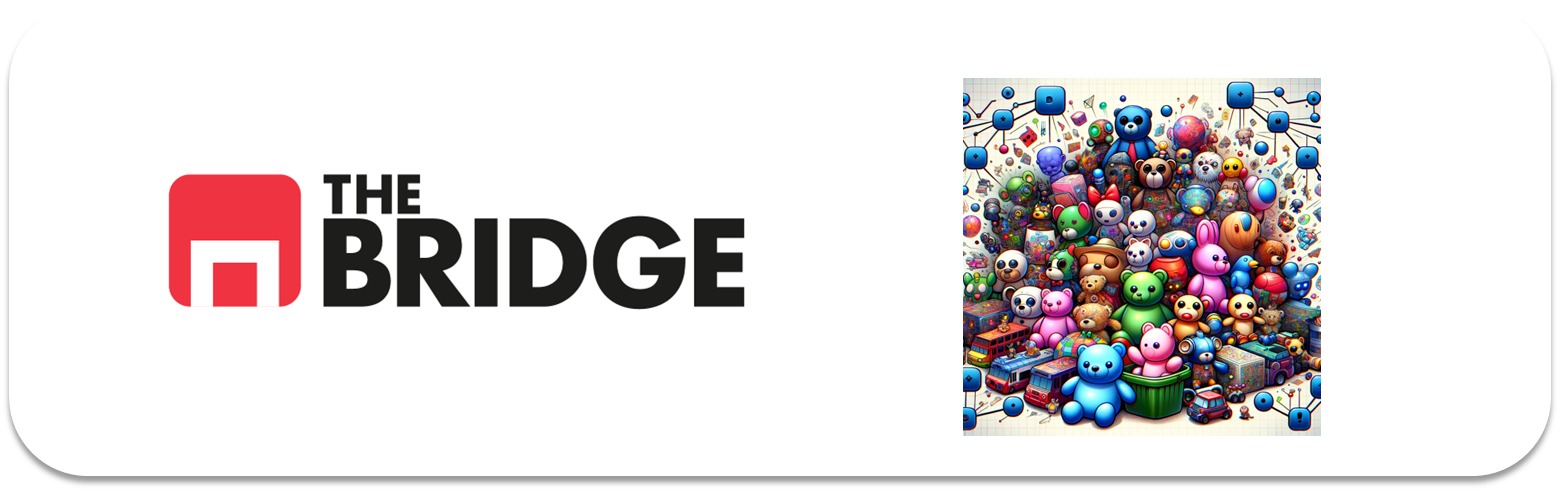

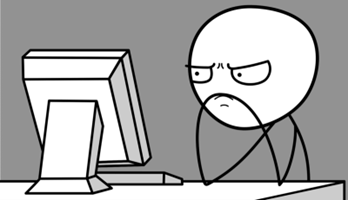

Para ejercitarte y afianzar lo aprendido sobre **DBSCAN**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Problema y "justificación": DBSCAN

Como sabemos, existen diversas técnicas de clusterización comprendidas por algoritmos de machine learning no supervisados, cuya finalidad es agrupar distintos elementos de una data sin la necesidad de estar previamente etiquetados. 

Anteriormente utilizamos el algoritmo de KMeans, sin embargo, dicho algoritmo tiene algunas limitaciones, como el hecho de que no siempre es sencillo obtener un número de K clusters óptimo o que algunas distribuciones de datos no se ajustan a la agrupación por clusters debido a la naturaleza del algoritmo. Para estos casos existen diversos algoritmos de clusterización. 

A continuación, vamos a utilizar el algoritmo DBSCAN (Density-Based Spatial Clustering of Applications with Noise) para capturar grupos en data con patrones relativamente complejos.

Utilizaremos data de clientes de un distribuidor al por mayor, en el que se recogen por línea ventas a diferentes establecimientos y empresas de sus productos (aunque no se incluye el identificador de establecimiento) y cuyo objetivo es obtener agrupacioines interesantes (agrupaciones no predefinidas de productos que se suelen comprar juntos):

Features:

    1) FRESH: Gastos en productos frescos;
    2) MILK: Gastos en productos lacteos;
    3) GROCERY: Gastos en comestibles;
    4) FROZEN: Gastos en congelados;
    5) DETERGENTS_PAPER: Gastos en detergentes y derivados del papel;
    6) DELICATESSEN: Gatos en comestibles finos;
    7) CHANNEL: Canal que utilizan los clientes para vender - Horeca (Hotel/Restaurant/Cafeterías) o Retail channel (Al por menor);
    8) REGION: Región del cliente;

Fuente: https://archive.ics.uci.edu/ml/datasets/Wholesale+customers

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

from toolbox_ml.eda.core import (
    describe_df, tipifica_variables, 
    get_features_num_regression, 
    plot_features_num_regression, 
    get_features_cat_regression, 
    plot_features_cat_regression
)


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Ejercicio 1

Carga los datos y haz una primera exploración, incluyendo una descripción de las variables numéricas.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


$$***$$

In [4]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Es hora de hacer un miniEda (cuyo objetivo en el caso de clusterizacion no es obtener features para predicción de un target que no tenemos), cuyo objetivo es poder intuir posibles agrupaciones y su número, detectar si hay que hacer transformaciones y escalado en las variables y cuál

### Ejercicio 2



Pinta el histograma de las variables y determina cuáles podríamos considerar numéricas continuas y cuáles numéricas discretas (o categóricas)

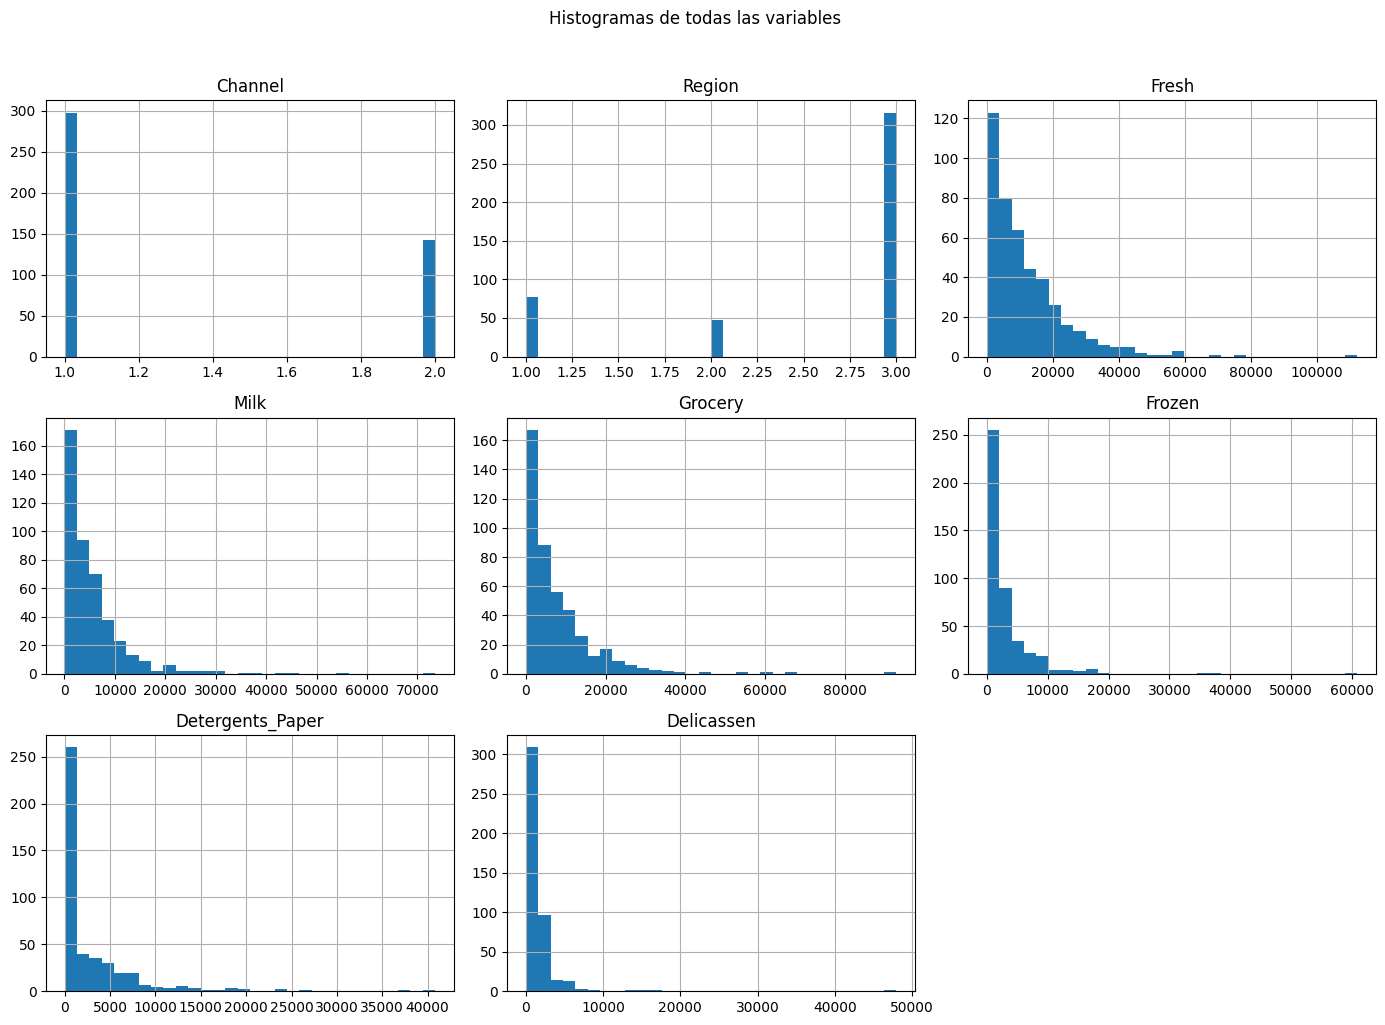

In [5]:
df.hist(bins=30, figsize=(14, 10))
plt.suptitle("Histogramas de todas las variables", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Channel,int64,0.0,2,0.45
Region,int64,0.0,3,0.68
Fresh,int64,0.0,433,98.41
Milk,int64,0.0,421,95.68
Grocery,int64,0.0,430,97.73
Frozen,int64,0.0,426,96.82
Detergents_Paper,int64,0.0,417,94.77
Delicassen,int64,0.0,403,91.59


In [7]:
tipifica_variables(df, umbral_categoria=10, umbral_continua=25)

,nombre_variable,tipo_sugerido
0,Channel,Binaria
1,Region,Categórica
2,Fresh,Numérica Continua
3,Milk,Numérica Continua
4,Grocery,Numérica Continua
5,Frozen,Numérica Continua
6,Detergents_Paper,Numérica Continua
7,Delicassen,Numérica Continua


### Ejercicio 3

Antes de decidir sobre las agrupaciones, vamos pintar los histrogramas pero separando por canal (ya que es un elemento muy diferenciador del tipo de venta que se realiza a mayorista). Muestra graficamente para cada variable numérica su histograma para cada canal (Horeca y Retail). 

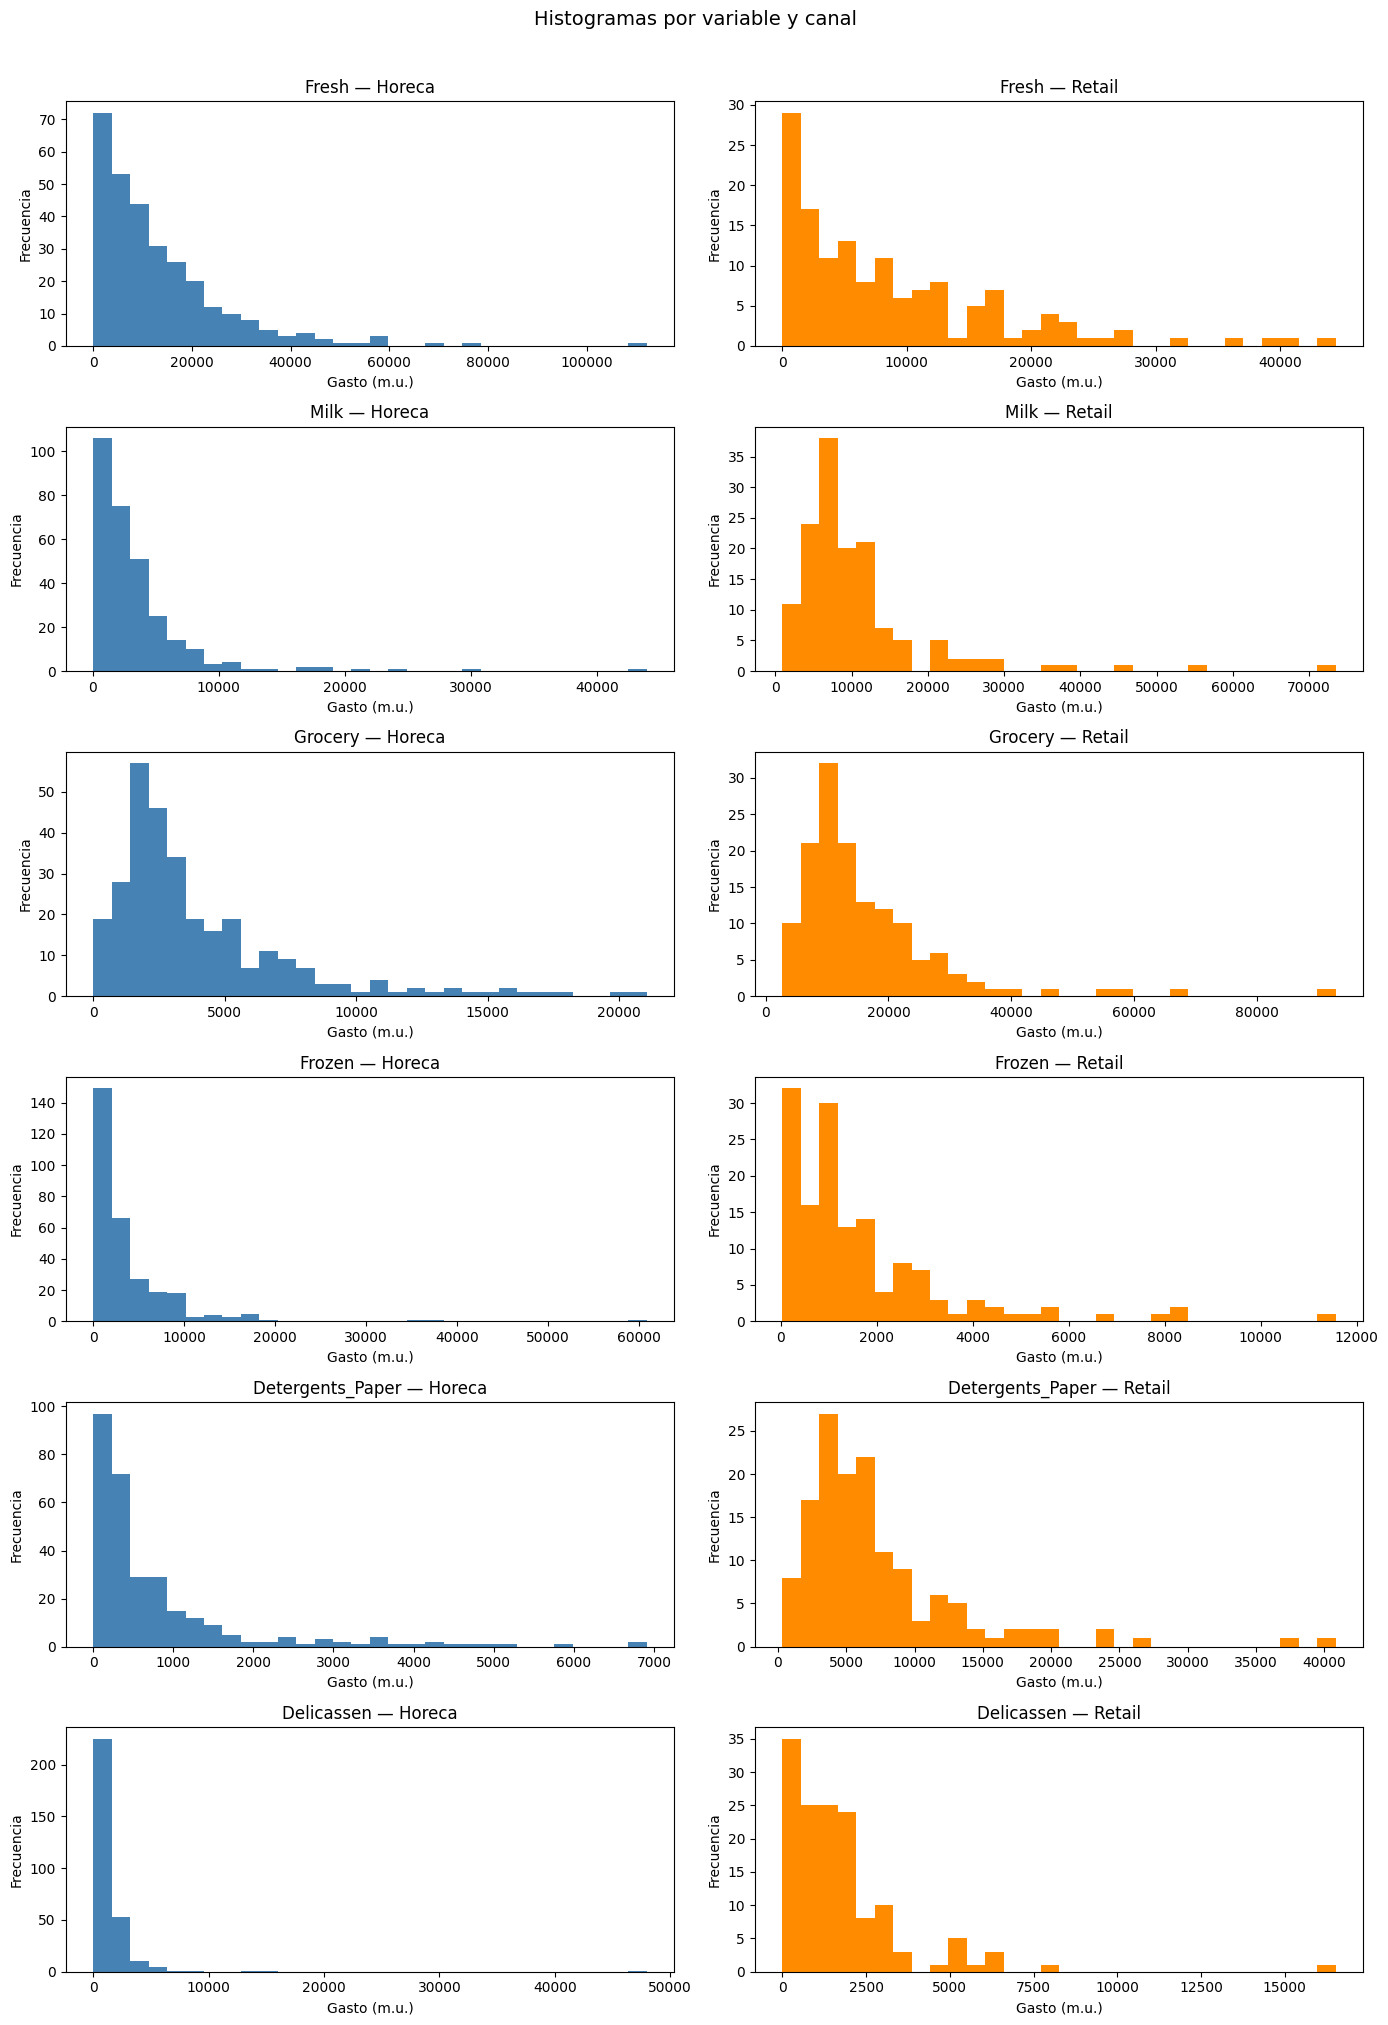

In [8]:
continuas = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

fig, axes = plt.subplots(6, 2, figsize=(14, 20))

for i, col in enumerate(continuas):
    for j, (canal, label) in enumerate([(1, 'Horeca'), (2, 'Retail')]):
        axes[i, j].hist(df[df['Channel'] == canal][col], bins=30, color='steelblue' if j == 0 else 'darkorange')
        axes[i, j].set_title(f'{col} — {label}')
        axes[i, j].set_xlabel('Gasto (m.u.)')
        axes[i, j].set_ylabel('Frecuencia')

plt.suptitle("Histogramas por variable y canal", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio 4

Analicemos los outliers. Obten los outliers a partir de los diagramas de boxplot para todos los datos y luego separados por canal.

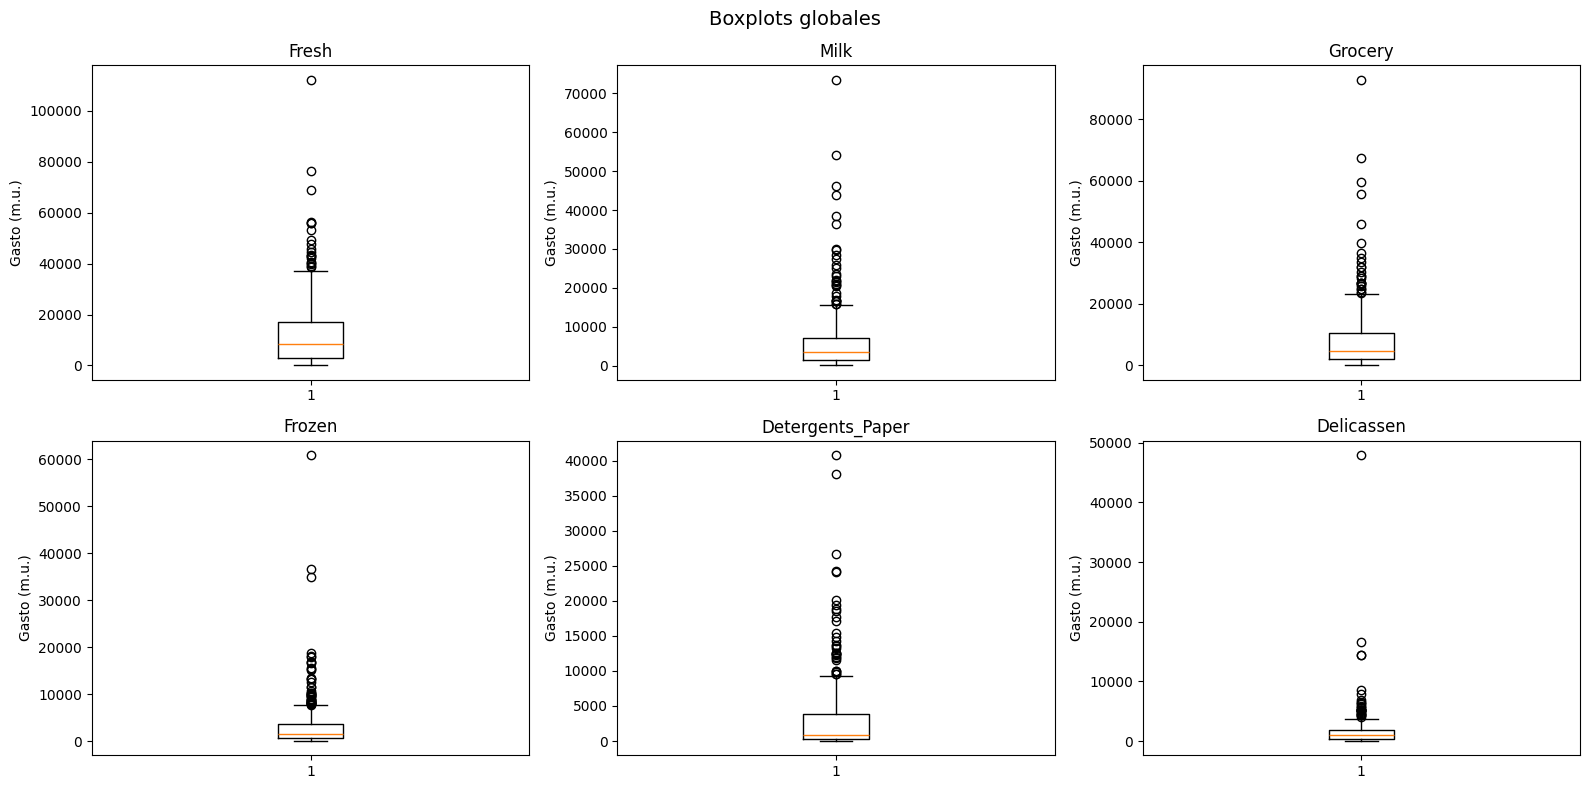

In [9]:
# Boxplots globales
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(continuas):
    ax = axes[i // 3][i % 3]
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
    ax.set_ylabel('Gasto (m.u.)')

plt.suptitle("Boxplots globales", fontsize=14)
plt.tight_layout()
plt.show()

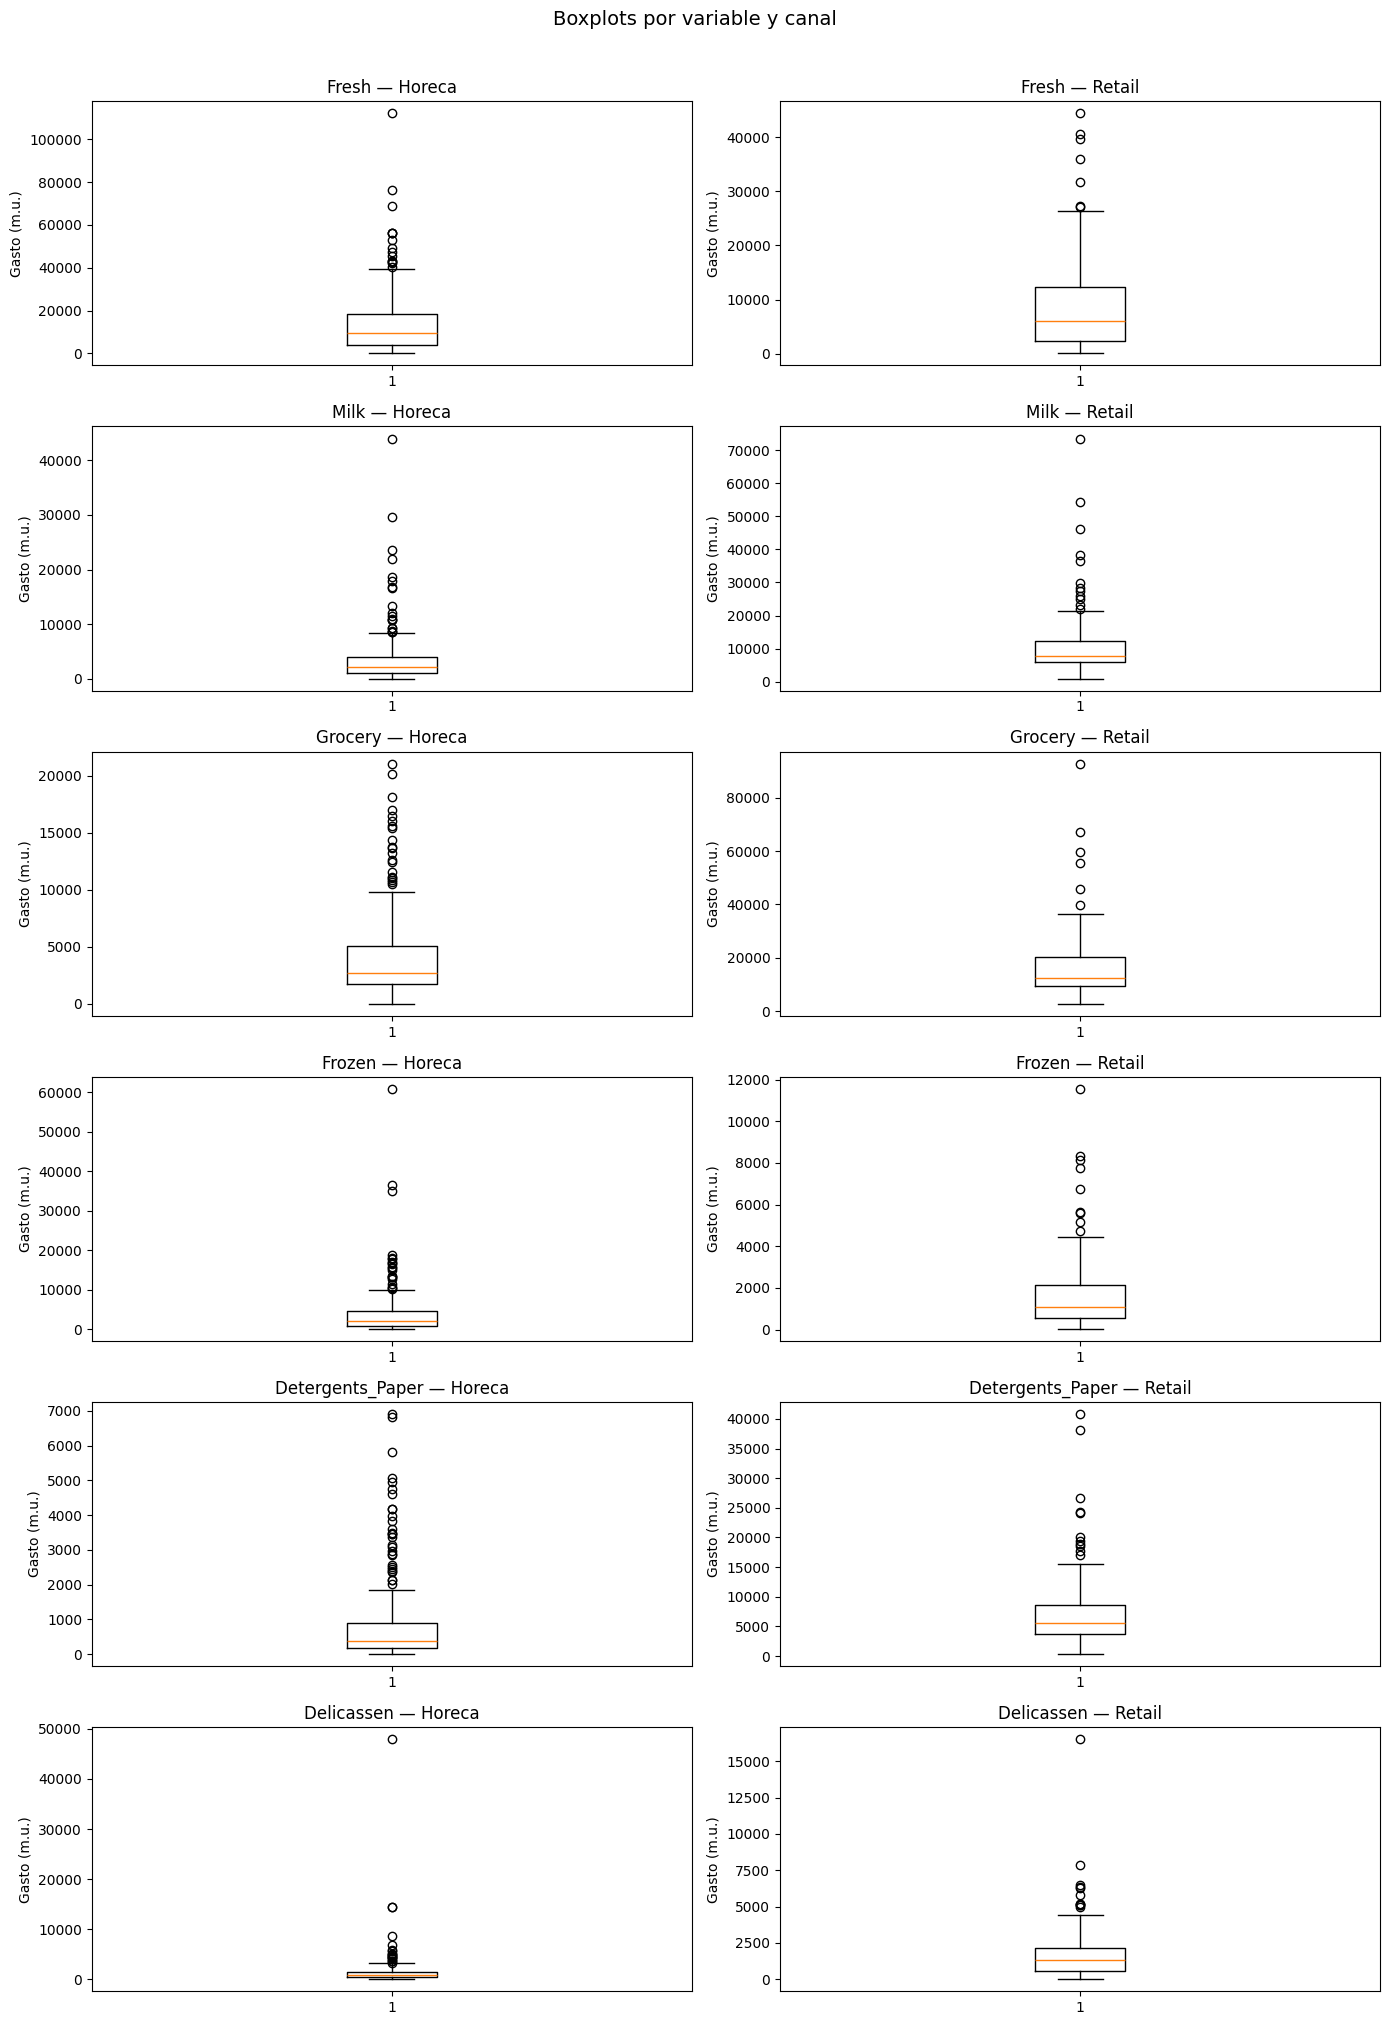

In [10]:
# Boxplots separados por canal
fig, axes = plt.subplots(6, 2, figsize=(14, 20))

for i, col in enumerate(continuas):
    for j, (canal, label) in enumerate([(1, 'Horeca'), (2, 'Retail')]):
        axes[i, j].boxplot(df[df['Channel'] == canal][col], vert=True)
        axes[i, j].set_title(f'{col} — {label}')
        axes[i, j].set_ylabel('Gasto (m.u.)')

plt.suptitle("Boxplots por variable y canal", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Ejercicio 5

Vamos a intentar detectar posibles agrupaciones en los datos con variables dos a dos. Utiliza un pairplot de sns para mostrar los scatter plots de las variables numéricas dos a dos e intentar visualizar algún clustering e incluso justificar usar kMeans o DBSCAN. En este ejercicio hazlo para todo el dataset.

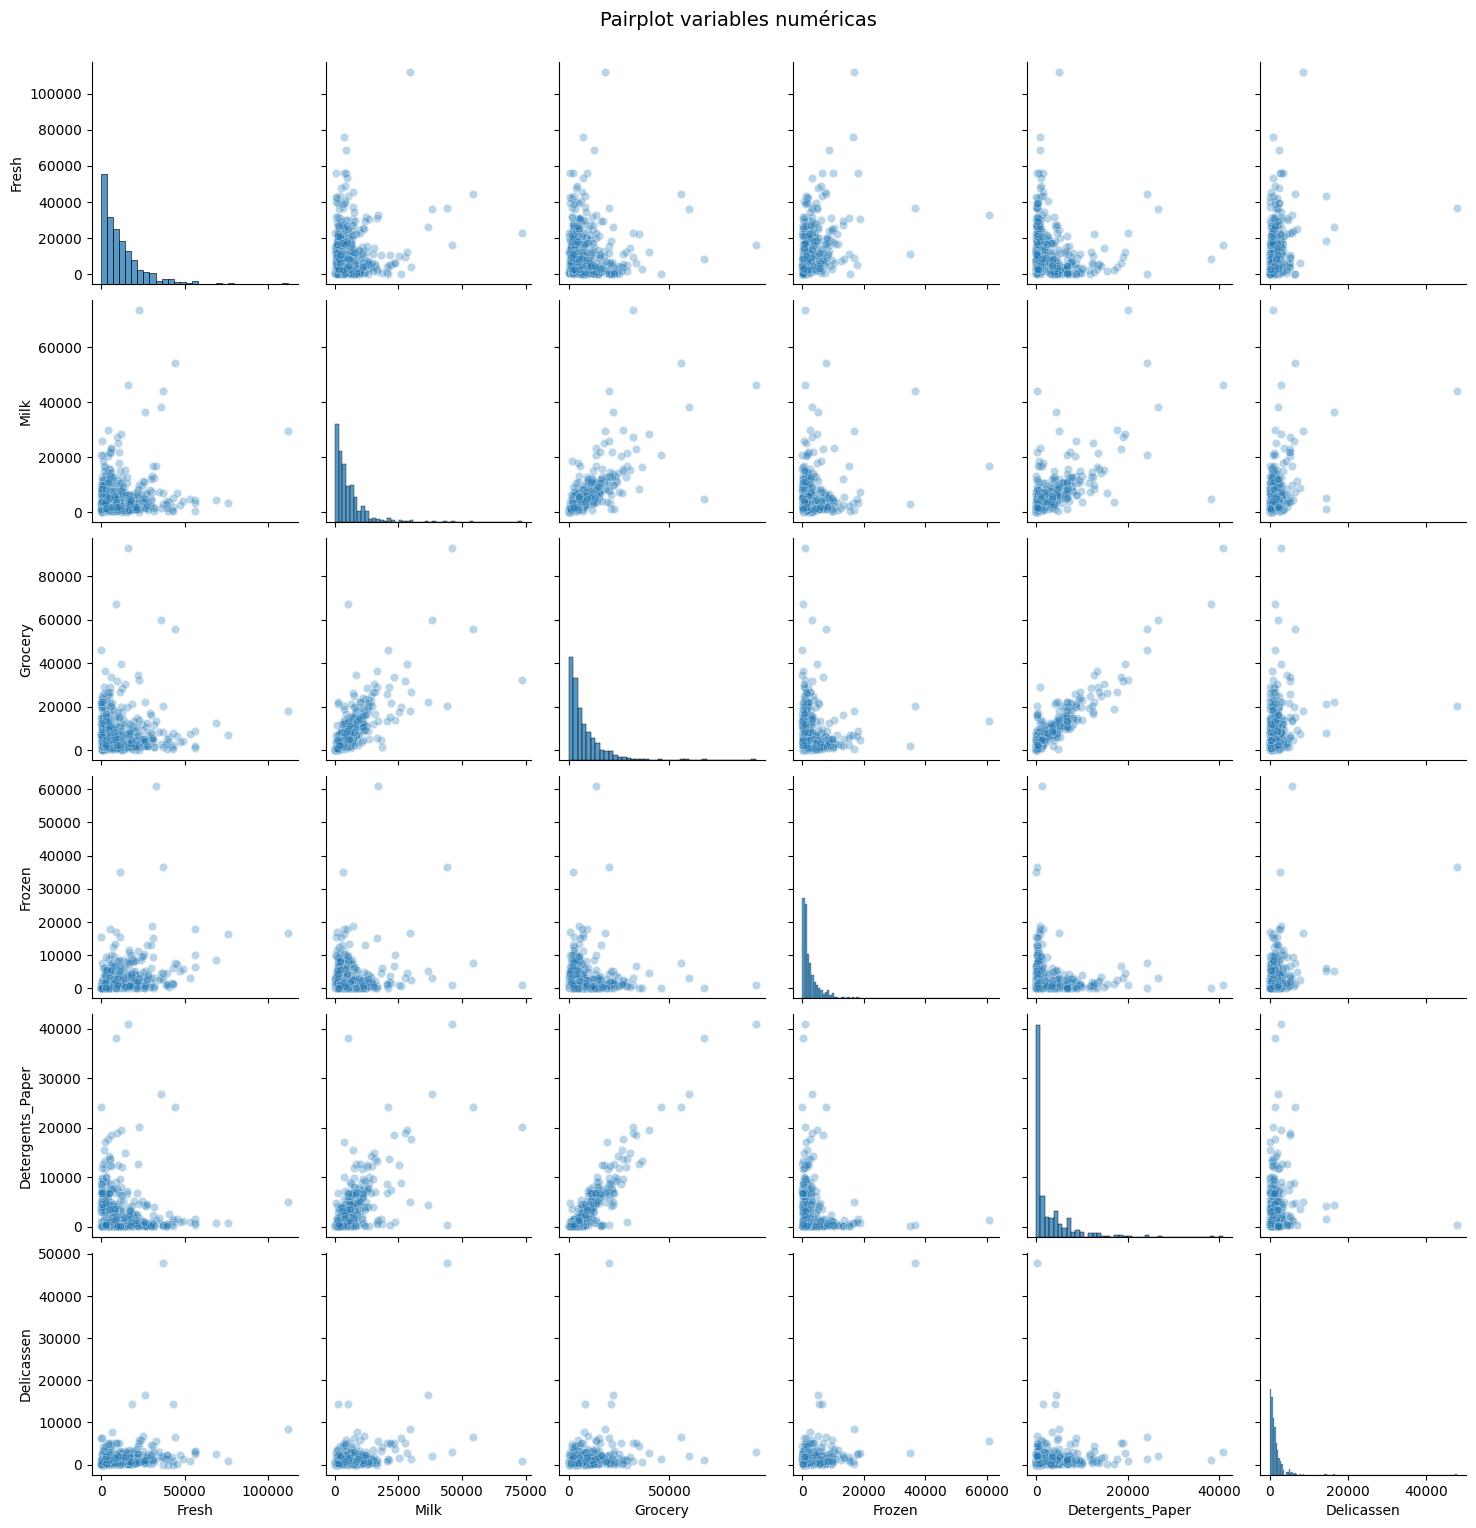

In [11]:
sns.pairplot(df[continuas], plot_kws={'alpha': 0.3}, diag_kind='hist')
plt.suptitle("Pairplot variables numéricas", y=1.02, fontsize=14)
plt.show()

## Conclusiones del Pairplot

### Forma de las nubes de puntos
En todos los scatter plots la masa de datos se concentra en la esquina inferior izquierda
(valores bajos) con puntos dispersos hacia valores altos. No se aprecian clusters esféricos
bien separados ni fronteras lineales claras entre grupos.

### ¿Se ven agrupaciones?
De forma muy tenue, sí:
- En `Milk` vs `Grocery` y `Milk` vs `Detergents_Paper` se intuye cierta separación entre
  un grupo denso en valores bajos y otro más disperso en valores altos, que probablemente
  corresponda a Horeca vs Retail.
- En el resto de combinaciones la nube es continua y sin separación clara.

### ¿KMeans o DBSCAN?

**KMeans no es ideal aquí** porque:
- Los clusters no tienen forma esférica ni tamaño similar.
- Los outliers extremos atraerían los centroides distorsionando las agrupaciones.

**DBSCAN es más apropiado** porque:
- Los datos forman regiones densas irregulares, no esferas.
- Hay outliers claros que DBSCAN etiquetará como ruido (−1) en lugar de forzarlos a un cluster.
- No es necesario especificar K de antemano.

### Conclusión del miniEDA
Antes de aplicar DBSCAN es necesario:
1. Trabajar solo con las 6 variables continuas de gasto (`Fresh`, `Milk`, `Grocery`,
   `Frozen`, `Detergents_Paper`, `Delicassen`).
2. Aplicar **transformación logarítmica** para comprimir las colas y reducir el efecto
   de los outliers extremos en el cálculo de distancias.
3. Aplicar **escalado** para igualar magnitudes entre variables.

### Ejercicio 6

Repite el ejercicio 5 pero separando por canal. Emplea el argumento hue del pairplot para no tener que hacer dos pairplots diferentes. 

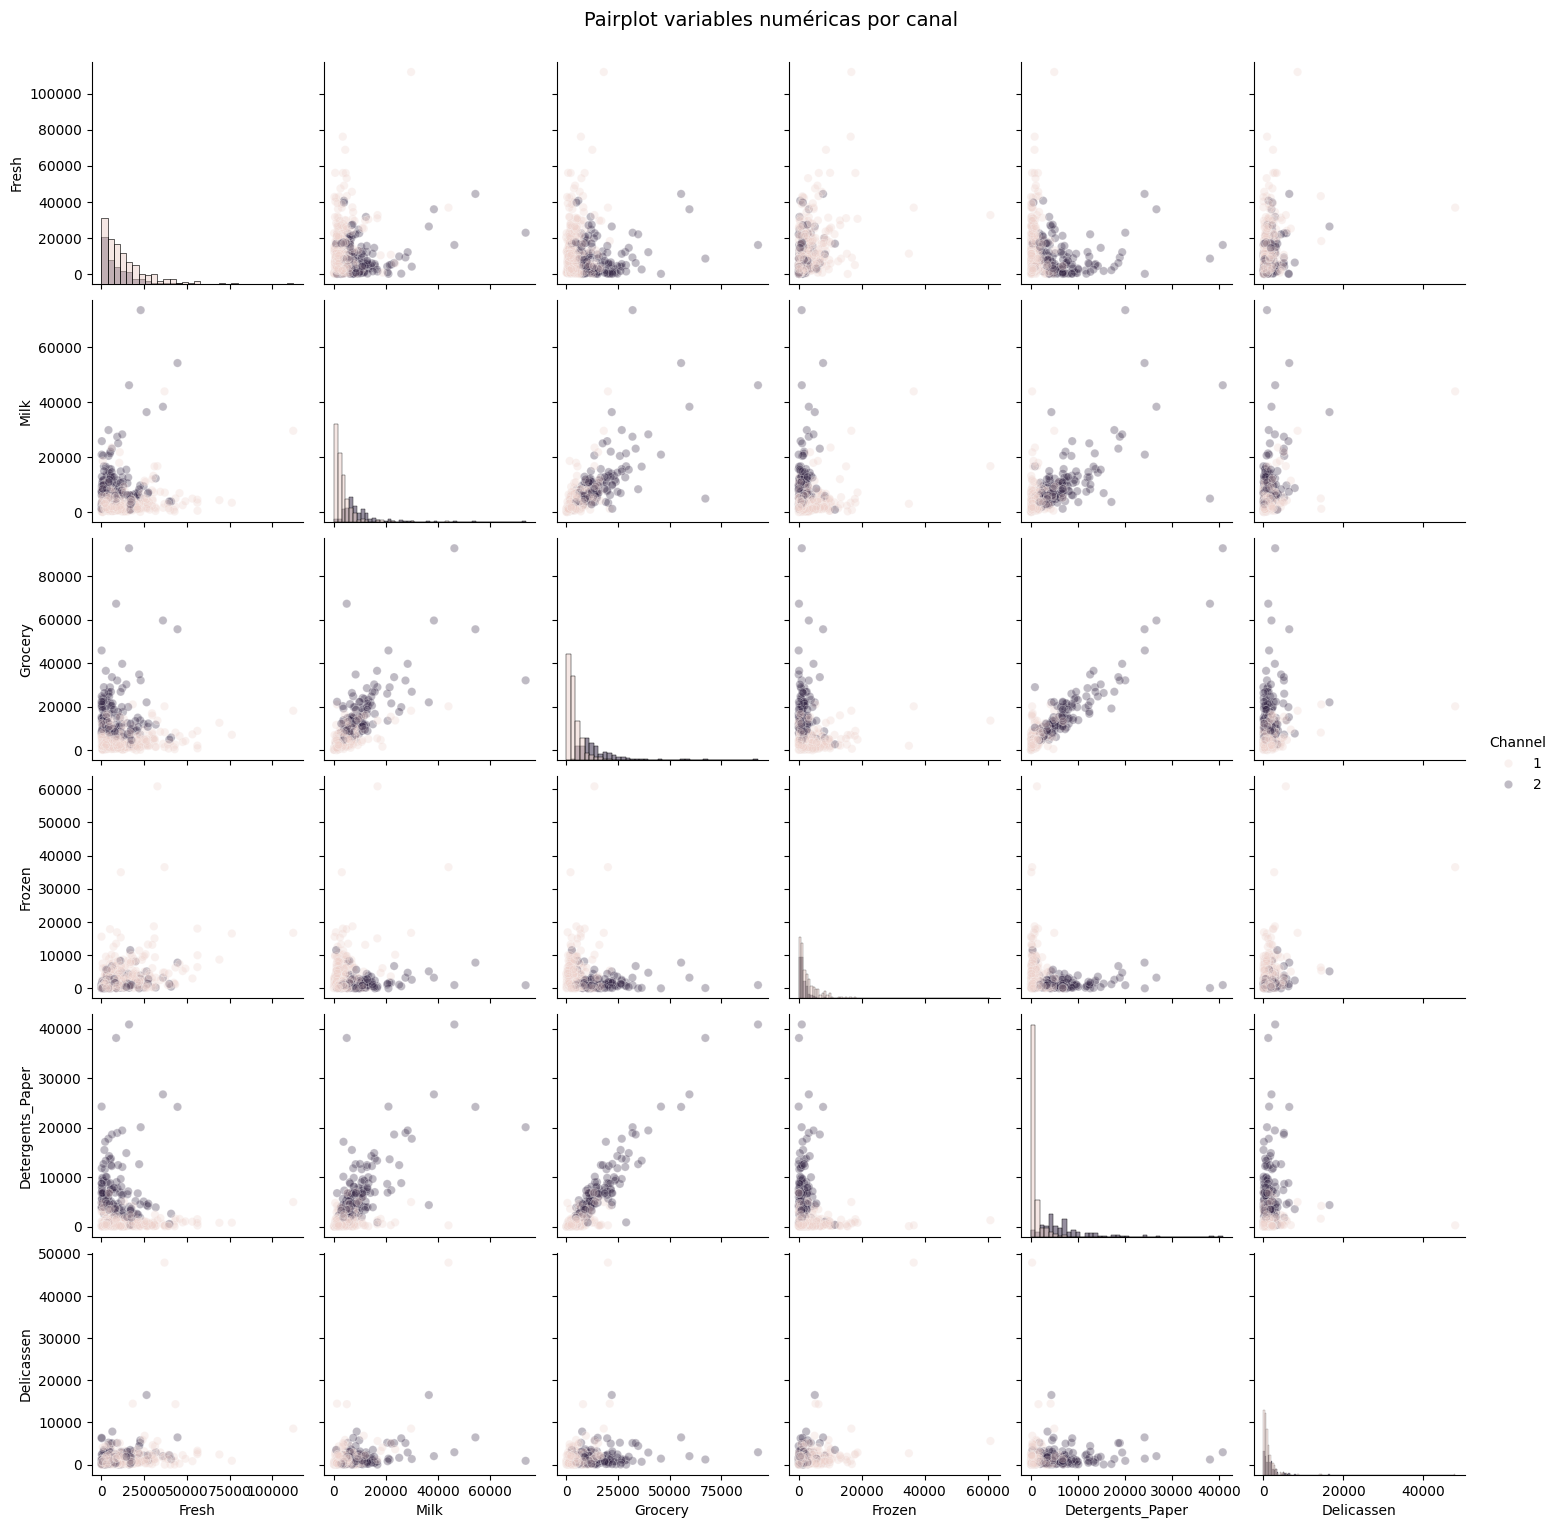

In [12]:
sns.pairplot(df[continuas + ['Channel']], hue='Channel', plot_kws={'alpha': 0.3}, diag_kind='hist')
plt.suptitle("Pairplot variables numéricas por canal", y=1.02, fontsize=14)
plt.show()

## Conclusiones del Pairplot por Canal

### Separación entre canales
Al colorear por canal (Horeca vs Retail) se aprecian diferencias claras que no eran
visibles en el pairplot global:

- **`Grocery` vs `Detergents_Paper`** y **`Milk` vs `Detergents_Paper`**: la separación
  más nítida del pairplot. Retail se desplaza claramente hacia valores altos en ambas
  variables, mientras Horeca se agrupa en valores bajos. Son las variables más
  discriminantes entre canales.
- **`Fresh` vs cualquier variable**: Horeca tiende a valores más altos de `Fresh`,
  pero hay mucho solapamiento con Retail.
- **`Frozen` y `Delicassen`**: sin separación clara entre canales en ninguna combinación.

### ¿Refuerza el uso de DBSCAN?
Sí, por dos razones adicionales:
- Las nubes por canal no son esféricas ni de tamaño similar, lo que descarta KMeans.
- Hay puntos aislados de ambos canales en zonas de baja densidad que DBSCAN identificará
  como ruido (label = −1), evitando que distorsionen los clusters principales.

### Conclusión clave
`Grocery`, `Detergents_Paper` y `Milk` son las variables que mejor separan los dos canales
y probablemente las más influyentes en la formación de clusters. `Frozen` y `Delicassen`
aportarán menos señal discriminante.

### Ejercicio 7

Si has logrado hacer los dos ejercicios anteriores (y si no consulta su solución) tendrás una idea un poco más clara de por qué es interesante la clusterización con DBSCAN mejor que con KMeans. Así que vamos a utilizarlo, pero antes escalemos los datos, transformándolos primero (de primeras no vamos a distinguir entre canales, hazlo con todo el dataseet). Es decir aplica la tranformación que creas necesaria en las columnas numéricas que creas conveniente. Hazlo en un dataframe copiado del original para poder interpretar los valores correctamente al final.

In [13]:
from sklearn.preprocessing import StandardScaler

# Copia del dataframe original
df_model = df[continuas].copy()

# Transformación logarítmica para comprimir colas y reducir efecto de outliers
df_model = np.log1p(df_model)

# Escalado
scaler = StandardScaler()
df_model[continuas] = scaler.fit_transform(df_model)

df_model.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


## Decisiones de Preprocesado

### Variables utilizadas
Se trabaja únicamente con las 6 variables continuas de gasto (`Fresh`, `Milk`, `Grocery`,
`Frozen`, `Detergents_Paper`, `Delicassen`). `Channel` y `Region` se excluyen por ser
categóricas: incluirlas distorsionaría el cálculo de distancias de DBSCAN.

### Transformación logarítmica (`log1p`)
Todas las variables continuas presentan fuerte sesgo positivo (cola larga a la derecha)
con outliers extremos. Se aplica `np.log1p` para:
- Comprimir las colas y reducir el efecto de los valores extremos en las distancias.
- Aproximar las distribuciones a una forma más simétrica.

Se usa `log1p` en lugar de `log` para evitar problemas numéricos en caso de que hubiera
ceros (log(0) = −∞), aunque en este dataset no los hay.

### Escalado (`StandardScaler`)
Tras el log se aplica `StandardScaler` para centrar cada variable en 0 con desviación
típica 1. Esto es necesario porque DBSCAN usa distancias y sin escalar las variables con
mayor magnitud

### Ejercicio 8

Escala las columnas que creas necesario. Si no lo tienes claro, escala todas.

### Ejercicio 9

En el caso de los modelos no supervisados, una vez hemos tratado las features hay que escoger los hiperparámetros. En el caso de dBSCAN no es el número de clústeres, sino la distancia `eps` que determina el vecindario de un punto y el número de vecinos a partir del cual se decide si una instancia es core o no (`min_samples`). 

Una forma de hacerlo es iterar sobre rangos de estos dos hiperparámetros midiendo el porentaje de "anomalías" que detecta y considerando como punto de parada un valor por debajo del 10%.

NOTA: Usa el doble de cantidad de tus features para el mínimo de elementos y un rango para el epsilon de 0.001 a 3. Para min_samples vamos a usar un valor "estimado" que corresponde a 2 veces el número de features empleadas.

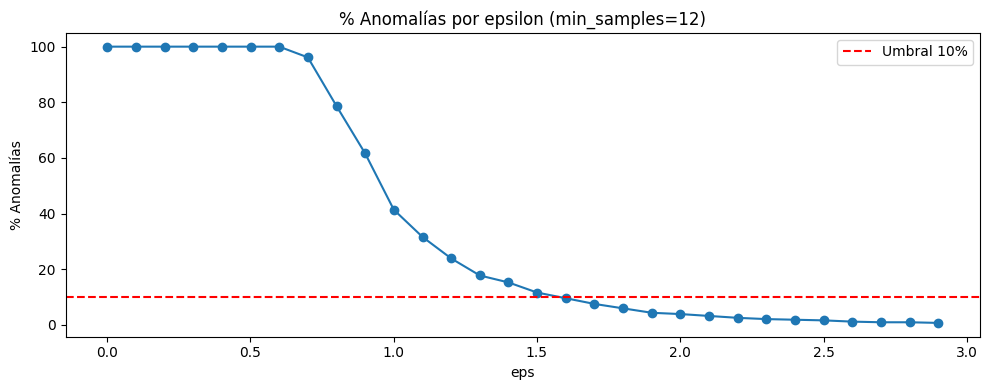

      eps  pct_anomalias
16  1.601           9.55
17  1.701           7.50
18  1.801           5.91
19  1.901           4.32
20  2.001           3.86
21  2.101           3.18
22  2.201           2.50
23  2.301           2.05
24  2.401           1.82
25  2.501           1.59


In [14]:
min_samples = 2 * len(continuas)  # 2 * 6 = 12
eps_range = np.arange(0.001, 3, 0.1)

resultados = []

for eps in eps_range:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_model)
    pct_anomalias = (labels == -1).sum() / len(labels) * 100
    resultados.append({'eps': round(eps, 3), 'pct_anomalias': round(pct_anomalias, 2)})

resultados_df = pd.DataFrame(resultados)

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(resultados_df['eps'], resultados_df['pct_anomalias'], marker='o')
plt.axhline(y=10, color='red', linestyle='--', label='Umbral 10%')
plt.xlabel('eps')
plt.ylabel('% Anomalías')
plt.title(f'% Anomalías por epsilon (min_samples={min_samples})')
plt.legend()
plt.tight_layout()
plt.show()

# Tabla: primeros eps por debajo del 10%
print(resultados_df[resultados_df['pct_anomalias'] < 10].head(10))

### Ejercicio 10

Entrena un clustering DBSCAN con el valor que hayas encontrado como mejor en el ejercicio anterior (si no has visto claramente un valor, usa eps = 2) y `min_samples` a dos veces el número de features empleadas.

In [15]:
dbscan_final = DBSCAN(eps=1.1, min_samples=min_samples)

# Distribución de clusters
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    nombre = "Anomalías" if cluster == -1 else f"Cluster {cluster}"
    print(f"{nombre}: {count} instancias ({count/len(labels)*100:.1f}%)")

Anomalías: 3 instancias (0.7%)
Cluster 0: 437 instancias (99.3%)


### Ejercicio 11

Agrega las etiquetas generadas con DBSCAN a tu dataframe original e interpreta los resultados (observa el número de etiquetas, recuerda que -1 no es un cluster son anomalías o outliers) luego contesta a: ¿Qué grupos o patrones fué capaz de capturar el DBSCAN? (Haz las tablas de contingencia de las etiquetas con las dos variables categóricas, por separado, por ejemplo y a partir de ahí justifica tu respuesta)

In [16]:
dbscan_final = DBSCAN(eps=1.1, min_samples=min_samples)
labels = dbscan_final.fit_predict(df_model)  # <-- esta línea faltaba

unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    nombre = "Anomalías" if cluster == -1 else f"Cluster {cluster}"
    print(f"{nombre}: {count} instancias ({count/len(labels)*100:.1f}%)")

Anomalías: 140 instancias (31.8%)
Cluster 0: 300 instancias (68.2%)


In [17]:
for eps_test in [0.8, 0.9, 1.0, 1.1, 1.2]:
    db = DBSCAN(eps=eps_test, min_samples=min_samples)
    lab = db.fit_predict(df_model)
    unique, counts = np.unique(lab, return_counts=True)
    n_clusters = len(unique) - (1 if -1 in unique else 0)
    pct_anomalias = (lab == -1).sum() / len(lab) * 100
    print(f"eps={eps_test} | clusters={n_clusters} | anomalías={pct_anomalias:.1f}%")

eps=0.8 | clusters=2 | anomalías=78.6%
eps=0.9 | clusters=2 | anomalías=62.0%
eps=1.0 | clusters=1 | anomalías=41.6%
eps=1.1 | clusters=1 | anomalías=31.8%
eps=1.2 | clusters=1 | anomalías=23.9%


In [18]:
for eps_test in np.arange(0.8, 1.0, 0.05):
    db = DBSCAN(eps=round(eps_test, 2), min_samples=min_samples)
    lab = db.fit_predict(df_model)
    unique, counts = np.unique(lab, return_counts=True)
    n_clusters = len(unique) - (1 if -1 in unique else 0)
    pct_anomalias = (lab == -1).sum() / len(lab) * 100
    print(f"eps={round(eps_test,2)} | clusters={n_clusters} | anomalías={pct_anomalias:.1f}%")

eps=0.8 | clusters=2 | anomalías=78.6%
eps=0.85 | clusters=2 | anomalías=72.0%
eps=0.9 | clusters=2 | anomalías=62.0%
eps=0.95 | clusters=1 | anomalías=51.6%


In [19]:
# Modelo final con eps=2
dbscan_final = DBSCAN(eps=2, min_samples=min_samples)
labels = dbscan_final.fit_predict(df_model)

# Agregar etiquetas al dataframe original
df['cluster'] = labels

print("Distribución de clusters:")
print(df['cluster'].value_counts().sort_index())

Distribución de clusters:
cluster
-1     17
 0    423
Name: count, dtype: int64


In [20]:
print("Cluster vs Channel:")
print(pd.crosstab(df['cluster'], df['Channel'],
                  rownames=['Cluster'], colnames=['Channel'],
                  margins=True))

Cluster vs Channel:
Channel    1    2  All
Cluster               
-1        13    4   17
0        285  138  423
All      298  142  440


In [21]:
print("\nCluster vs Region:")
print(pd.crosstab(df['cluster'], df['Region'],
                  rownames=['Cluster'], colnames=['Region'],
                  margins=True))


Cluster vs Region:
Region    1   2    3  All
Cluster                  
-1        1   1   15   17
0        76  46  301  423
All      77  47  316  440


In [22]:
print("\nMedias por cluster (valores originales):")
print(df.groupby('cluster')[continuas].mean().round(0))


Medias por cluster (valores originales):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
cluster                                                                
-1       12507.0  8638.0  11409.0  5048.0            2969.0      3570.0
 0       11980.0  5682.0   7812.0  2993.0            2878.0      1443.0


## Interpretación de Resultados DBSCAN (eps=2, min_samples=12)

### Distribución general
DBSCAN identificó 1 cluster principal (423 instancias, 96.1%) y 17 anomalías (3.9%).

### Cluster vs Channel
- El cluster 0 mantiene la proporción original del dataset (~67% Horeca, ~33% Retail).
  DBSCAN **no separó los canales**, los agrupó todos en una única región densa.
- Las anomalías son mayoritariamente Horeca (13 de 17), lo que sugiere que los outliers
  extremos de `Fresh` y `Frozen` vistos en los boxplots corresponden a clientes Horeca
  con patrones de gasto muy atípicos.

### Cluster vs Region
- Las anomalías se concentran en la región 3 — Otra región (15 de 17), que es también
  la más numerosa del dataset. No hay un patrón geográfico claro más allá del peso
  proporcional de cada región.

### Medias por cluster (valores originales)
- Las anomalías gastan más